In [1]:
print("Jupyter is working!")

Jupyter is working!


In [2]:
marks = [85, 92, 78, 95, 88]
print(marks)

[85, 92, 78, 95, 88]


In [3]:
print(marks[0])
print(marks[2])
print(len(marks))

85
78
5


In [4]:
import numpy

In [5]:
import pandas

In [6]:
import matplotlib

In [7]:
import pandas as pd

data = {
    "Name": ["Alice", "Bob", "Charlie", "David"],
    "Age": [24, 27, 22, 25],
    "Salary": [50000, 60000, 45000, 70000]
}

df = pd.DataFrame(data)
print(df)

      Name  Age  Salary
0    Alice   24   50000
1      Bob   27   60000
2  Charlie   22   45000
3    David   25   70000


In [8]:
df

,Name,Age,Salary
0,Alice,24,50000
1,Bob,27,60000
2,Charlie,22,45000
3,David,25,70000


In [9]:
print(df)

      Name  Age  Salary
0    Alice   24   50000
1      Bob   27   60000
2  Charlie   22   45000
3    David   25   70000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    4 non-null      str  
 1   Age     4 non-null      int64
 2   Salary  4 non-null      int64
dtypes: int64(2), str(1)
memory usage: 228.0 bytes


In [11]:
df.describe()

,Age,Salary
count,4.000000,4.000000
mean,24.500000,56250.000000
std,2.081666,11086.778913
min,22.000000,45000.000000
25%,23.500000,48750.000000
50%,24.500000,55000.000000
75%,25.500000,62500.000000
max,27.000000,70000.000000


In [12]:
df.describe()

,Age,Salary
count,4.000000,4.000000
mean,24.500000,56250.000000
std,2.081666,11086.778913
min,22.000000,45000.000000
25%,23.500000,48750.000000
50%,24.500000,55000.000000
75%,25.500000,62500.000000
max,27.000000,70000.000000


In [13]:
import pandas as pd
df = pd.read_csv("archive/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
# Drop Cabin
df = df.drop(columns=["Cabin"])

# Fill Age with mean
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill Embarked with most common value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Check if any missing values remain
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [16]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

df[["Sex", "Embarked"]].head()

,Sex,Embarked
0,0,0
1,1,1
2,1,0
3,1,0
4,0,0


In [17]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

X = df[features]  # inputs
y = df["Survived"]  # what we want to predict

print(X.shape)
print(y.shape)

(891, 7)
(891,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [20]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8212290502793296


In [21]:
import numpy as np

# Chaitanya boards the Titanic
# 20 years old, male, 3rd class, no siblings, no parents, paid 7.25, boarded at S
chaitanya = np.array([[3, 0, 20, 0, 0, 7.25, 0]])

result = model.predict(chaitanya)

if result[0] == 1:
    print("Chaitanya survived!")
else:
    print("Chaitanya did not survive.")

Chaitanya did not survive.


C:\Users\chait\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [22]:
# Rich young woman, 1st class
passenger = np.array([[1, 1, 25, 0, 0, 71.0, 1]])

result = model.predict(passenger)

if result[0] == 1:
    print("Survived!")
else:
    print("Did not survive.")

Survived!


C:\Users\chait\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


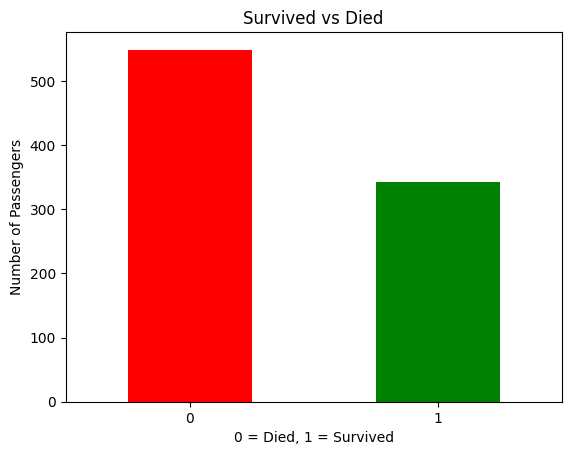

In [23]:
import matplotlib.pyplot as plt

# How many survived vs died
df["Survived"].value_counts().plot(kind="bar", color=["red", "green"])

plt.title("Survived vs Died")
plt.xlabel("0 = Died, 1 = Survived")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.show()

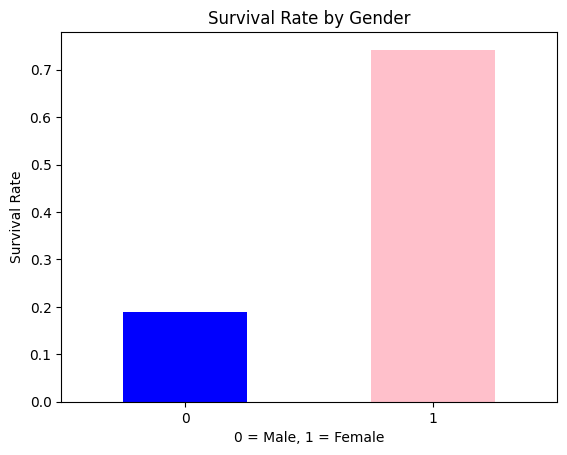

In [24]:
df.groupby("Sex")["Survived"].mean().plot(kind="bar", color=["blue", "pink"])

plt.title("Survival Rate by Gender")
plt.xlabel("0 = Male, 1 = Female")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

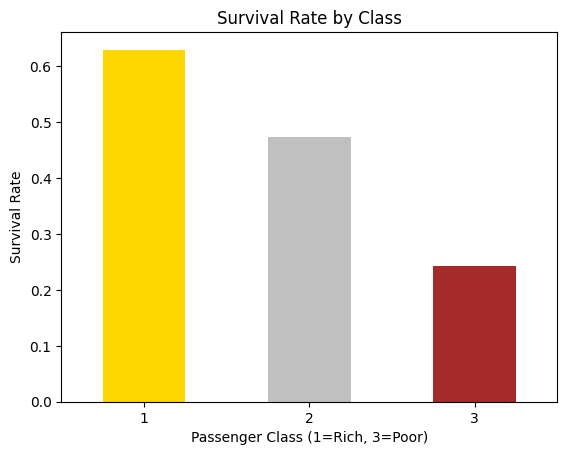

In [25]:
df.groupby("Pclass")["Survived"].mean().plot(kind="bar", color=["gold", "silver", "brown"])

plt.title("Survival Rate by Class")
plt.xlabel("Passenger Class (1=Rich, 3=Poor)")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

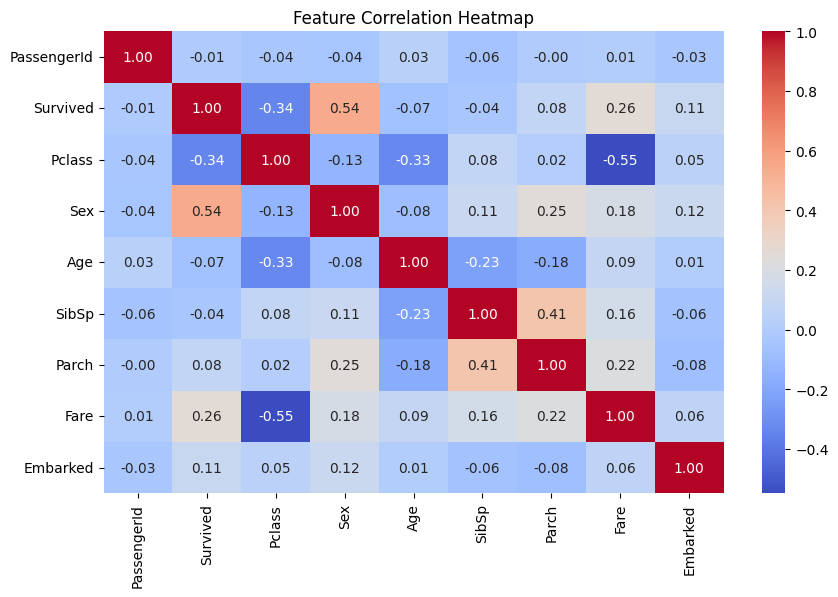

In [26]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=["Name", "Ticket"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Logistic Regression
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")

Logistic Regression Accuracy: 79.89%


In [28]:
from sklearn.svm import SVC

# SVM
svm_model = SVC()
svm_model.fit(X_train, y_train)
svm_predictions = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_predictions)

print(f"SVM Accuracy: {svm_accuracy:.2%}")

SVM Accuracy: 65.36%


In [29]:
from sklearn.neighbors import KNeighborsClassifier

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_predictions)

print(f"KNN Accuracy: {knn_accuracy:.2%}")

KNN Accuracy: 70.39%


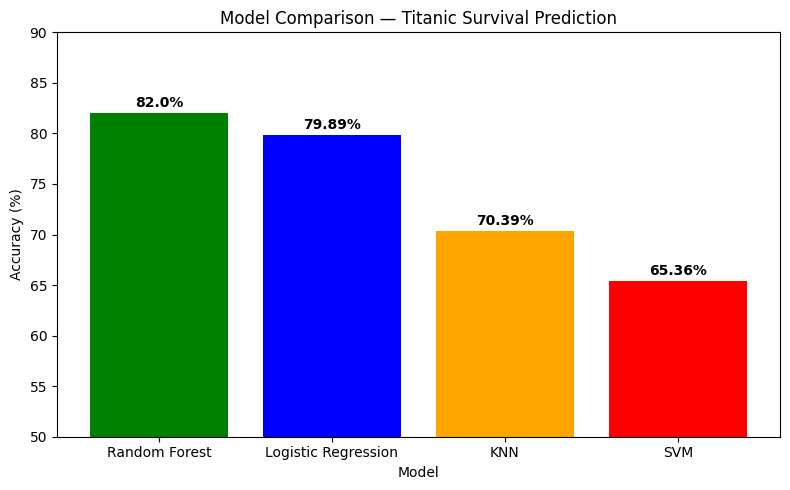

In [30]:
import matplotlib.pyplot as plt

# Data
models = ['Random Forest', 'Logistic Regression', 'KNN', 'SVM']
accuracies = [82.00, 79.89, 70.39, 65.36]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['green', 'blue', 'orange', 'red'])
plt.ylim(50, 90)
plt.title('Model Comparison — Titanic Survival Prediction')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')

# Add accuracy number on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{acc}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

In [34]:
# Check accuracy of first 5 individual trees
for i in range(5):
    single_tree = model.estimators_[i]
    acc = accuracy_score(y_test, single_tree.predict(X_test))
    print(f"Tree {i} accuracy: {acc:.2%}")

print(f"\nFull Forest accuracy: 82.00%")

Tree 0 accuracy: 77.09%
Tree 1 accuracy: 76.54%
Tree 2 accuracy: 74.86%
Tree 3 accuracy: 78.77%
Tree 4 accuracy: 81.01%

Full Forest accuracy: 82.00%


C:\Users\chait\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\chait\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\chait\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\chait\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\chait\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has fe

In [35]:
from sklearn.tree import export_text

tree_0 = export_text(model.estimators_[0],
                     max_depth=3)

tree_1 = export_text(model.estimators_[1],
                     max_depth=3)

print("=== TREE 0 ===")
print(tree_0)
print("=== TREE 1 ===")
print(tree_1)

=== TREE 0 ===
|--- feature_4 <= 0.50
|   |--- feature_2 <= 16.50
|   |   |--- feature_5 <= 11.25
|   |   |   |--- class: 1.0
|   |   |--- feature_5 >  11.25
|   |   |   |--- feature_2 <= 14.25
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- feature_2 >  14.25
|   |   |   |   |--- class: 0.0
|   |--- feature_2 >  16.50
|   |   |--- feature_6 <= 0.50
|   |   |   |--- feature_3 <= 2.50
|   |   |   |   |--- truncated branch of depth 16
|   |   |   |--- feature_3 >  2.50
|   |   |   |   |--- class: 1.0
|   |   |--- feature_6 >  0.50
|   |   |   |--- feature_6 <= 1.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- feature_6 >  1.50
|   |   |   |   |--- truncated branch of depth 9
|--- feature_4 >  0.50
|   |--- feature_5 <= 78.24
|   |   |--- feature_0 <= 2.50
|   |   |   |--- feature_2 <= 50.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- feature_2 >  50.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- feature_0 >  2

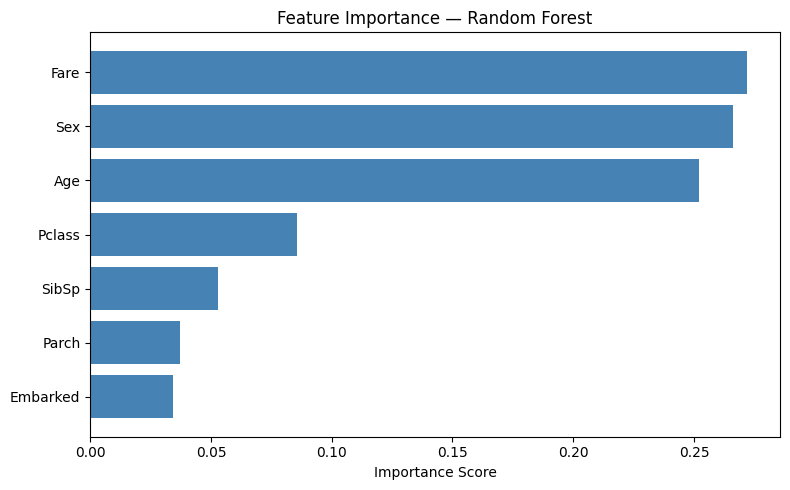

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
feature_names = X_test.columns
importances = model.feature_importances_

# Put into DataFrame and sort
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler

# Create the scaler — hire the fair invigilator
scaler = StandardScaler()

# Invigilator studies training data and rescales it
X_train_scaled = scaler.fit_transform(X_train)

# Invigilator applies same scale to test data
X_test_scaled = scaler.transform(X_test)

In [39]:
# Retrain SVM on scaled data
svm_scaled_model = SVC()
svm_scaled_model.fit(X_train_scaled, y_train)
svm_scaled_predictions = svm_scaled_model.predict(X_test_scaled)
svm_scaled_accuracy = accuracy_score(y_test, svm_scaled_predictions)

print(f"SVM Before Scaling: 65.36%")
print(f"SVM After Scaling:  {svm_scaled_accuracy:.2%}")

SVM Before Scaling: 65.36%
SVM After Scaling:  82.12%


In [40]:
# Retrain KNN on scaled data
knn_scaled_model = KNeighborsClassifier(n_neighbors=5)
knn_scaled_model.fit(X_train_scaled, y_train)
knn_scaled_predictions = knn_scaled_model.predict(X_test_scaled)
knn_scaled_accuracy = accuracy_score(y_test, knn_scaled_predictions)

print(f"KNN Before Scaling: 70.39%")
print(f"KNN After Scaling:  {knn_scaled_accuracy:.2%}")

KNN Before Scaling: 70.39%
KNN After Scaling:  80.45%


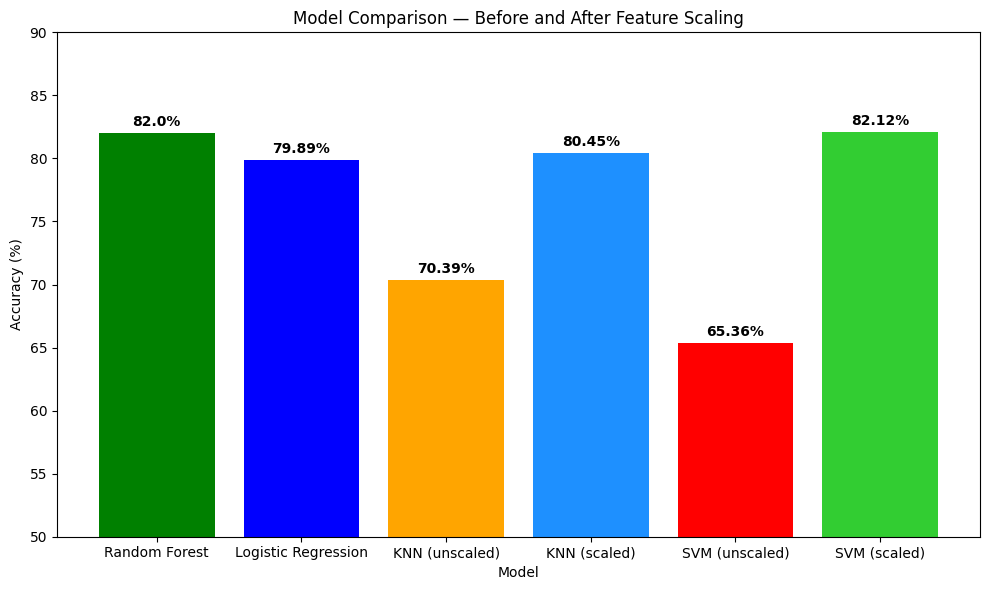

In [42]:
# Updated comparison chart with scaled results
models = ['Random Forest', 'Logistic Regression', 'KNN (unscaled)', 
          'KNN (scaled)', 'SVM (unscaled)', 'SVM (scaled)']

accuracies = [82.00, 79.89, 70.39, 80.45, 65.36, 82.12]

colors = ['green', 'blue', 'orange', 'dodgerblue', 'red', 'limegreen']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors)
plt.ylim(50, 90)
plt.title('Model Comparison — Before and After Feature Scaling')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=0)

# Add accuracy number on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_updated.png')
plt.show()